## MovieIQ - Predictive Analystics on Film Success

#### Importing and Loading Libraries

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### CSV to Pandas DataFrame

In [102]:
df = pd.read_csv("movies_iq.csv")

#### Dataframe Structure

In [103]:
df.shape

(2000, 8)

#### Top 5 rows before Data Wrangling

In [104]:
df.head()

,title,genres,budget,revenue,popularity,runtime,vote_average,success
0,Movie 1,"[{'id': 10749, 'name': 'Romance'}]",57755036,107323371,60.38,98,6.61,1
1,Movie 2,"[{'id': 18, 'name': 'Drama'}]",192100010,342896533,86.29,96,7.18,1
2,Movie 3,"[{'id': 35, 'name': 'Comedy'}]",128521863,253206827,87.00,148,3.54,1
3,Movie 4,"[{'id': 18, 'name': 'Drama'}]",156299516,89635602,72.71,118,5.99,0
4,Movie 5,"[{'id': 35, 'name': 'Comedy'}]",148532820,221133868,74.83,161,4.58,1


#### Statistical View of Dataset

In [105]:
df.describe()

,budget,revenue,popularity,runtime,vote_average,success
count,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.00000,2000.000000
mean,1.019211e+08,1.780574e+08,50.090740,129.568000,6.03690,0.807000
std,5.682795e+07,1.293879e+08,28.481992,28.906507,1.74317,0.394752
min,1.070640e+06,1.138729e+06,1.020000,80.000000,3.01000,0.000000
25%,5.274832e+07,7.458306e+07,25.722500,104.000000,4.58000,1.000000
50%,1.026023e+08,1.484882e+08,50.210000,130.000000,6.05000,1.000000
75%,1.507962e+08,2.623679e+08,74.925000,155.000000,7.58000,1.000000
max,1.999879e+08,5.744901e+08,99.760000,179.000000,9.00000,1.000000


#### Datatypes of columns, checking existance null values if any, Data Types of columns and memory usage of dataset 

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         2000 non-null   str    
 1   genres        2000 non-null   str    
 2   budget        2000 non-null   int64  
 3   revenue       2000 non-null   int64  
 4   popularity    2000 non-null   float64
 5   runtime       2000 non-null   int64  
 6   vote_average  2000 non-null   float64
 7   success       2000 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 201.5 KB


#### Genre column is populated with dictionary as its data point, disctionary is having Movie_id and Genre_name

In [107]:
print(type(df['genres'][0]))

<class 'str'>


In [108]:
# since the genre column is having the movie_id and name of the genre in dictionary form which externally saved as list
# we need to parse it to real python dict format
import ast
#ast full form = Abstract Syntax Tree - To convert the string to its actual data type.
df['genres'] = df['genres'].apply(ast.literal_eval)

In [109]:
df.head()

,title,genres,budget,revenue,popularity,runtime,vote_average,success
0,Movie 1,"[{'id': 10749, 'name': 'Romance'}]",57755036,107323371,60.38,98,6.61,1
1,Movie 2,"[{'id': 18, 'name': 'Drama'}]",192100010,342896533,86.29,96,7.18,1
2,Movie 3,"[{'id': 35, 'name': 'Comedy'}]",128521863,253206827,87.00,148,3.54,1
3,Movie 4,"[{'id': 18, 'name': 'Drama'}]",156299516,89635602,72.71,118,5.99,0
4,Movie 5,"[{'id': 35, 'name': 'Comedy'}]",148532820,221133868,74.83,161,4.58,1


Successfully converted the genre string to actual list data type

In [110]:
print(type(df['genres'][0]))

<class 'list'>


#### New Movie_id Column extracted from genre column

In [111]:
df['movie_id'] = df['genres'].apply(lambda i:i[0]['id'] if len(i)>0 else None)

#### Lets consider the primary genre for each movie

In [112]:
df['genres'] = df['genres'].apply(lambda x:x[0]['name'] if len(x) > 0 else None)

In [113]:
df.head()

,title,genres,budget,revenue,popularity,runtime,vote_average,success,movie_id
0,Movie 1,Romance,57755036,107323371,60.38,98,6.61,1,10749.0
1,Movie 2,Drama,192100010,342896533,86.29,96,7.18,1,18.0
2,Movie 3,Comedy,128521863,253206827,87.00,148,3.54,1,35.0
3,Movie 4,Drama,156299516,89635602,72.71,118,5.99,0,18.0
4,Movie 5,Comedy,148532820,221133868,74.83,161,4.58,1,35.0


In [114]:
df.shape

(2000, 9)

In [115]:
df['genres'].isna().sum()

np.int64(181)

#### Filling null values with "N/A"

In [116]:
df['genres'] = df['genres'].fillna("N/A")

In [117]:
df['movie_id'] = df['movie_id'].fillna("N/A")

In [118]:
df.isna().sum()

title           0
genres          0
budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
success         0
movie_id        0
dtype: int64

In [119]:
df.head()

,title,genres,budget,revenue,popularity,runtime,vote_average,success,movie_id
0,Movie 1,Romance,57755036,107323371,60.38,98,6.61,1,10749.0
1,Movie 2,Drama,192100010,342896533,86.29,96,7.18,1,18.0
2,Movie 3,Comedy,128521863,253206827,87.00,148,3.54,1,35.0
3,Movie 4,Drama,156299516,89635602,72.71,118,5.99,0,18.0
4,Movie 5,Comedy,148532820,221133868,74.83,161,4.58,1,35.0


#### Q1. Scatter plot: does more budget lead to more revenue?

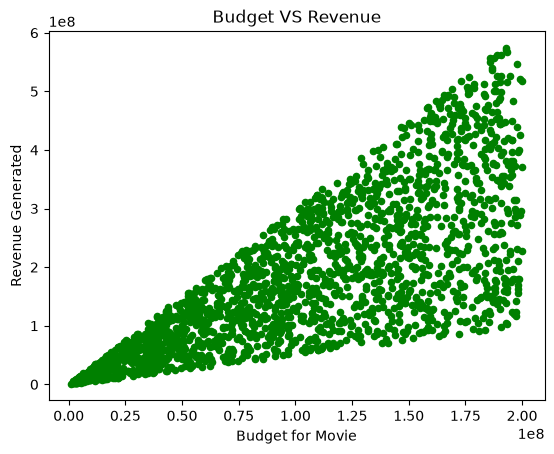

In [120]:
df.plot(kind='scatter',x='budget',y='revenue',color='green')
plt.title("Budget VS Revenue")
plt.xlabel("Budget for Movie")
plt.ylabel("Revenue Generated")
plt.show() 

#### +0.7 to +0.9 - Strong positive correlation between budget and revenue columns and a strong linear relationship

This correlation suggest that movies with higher budget tends to generate higher revenue with still have some exceptions exists

In [121]:
print(df['budget'].corr(df['revenue']))

0.7598481036220431


In [122]:
df.groupby(pd.cut(df['budget'], bins=4),observed=False)['success'].mean()

budget
(871722.733, 50799956.75]      0.812109
(50799956.75, 100529273.5]     0.829703
(100529273.5, 150258590.25]    0.801961
(150258590.25, 199987907.0]    0.784585
Name: success, dtype: float64

In [123]:
df['perfect_ratio'] = df['revenue']/df['budget']
df['perfect_ratio'].describe()

count    2000.000000
mean        1.753965
std         0.712996
min         0.500471
25%         1.135405
50%         1.781669
75%         2.368657
max         2.999285
Name: perfect_ratio, dtype: float64

In [124]:
df['perfect_ratio'].median()

np.float64(1.7816692982583802)

The Median above 👆 indicates that there are the movies in the dataset which earned 1.78 times its budget.
Half of the movies earned less that this multiple and half earned more than this.

**Findings:**
- Budget and revenue show a strong positive correlation (r ≈ 0.75).
- The median profit ratio is ~1.78, meaning a typical movie earns about 78% more revenue than its budget.
- Low-budget movies are consistently capped at low revenue, while high-budget movies show a much wider outcome range — from flops to major hits.

**Interpretation:** Budget appears to set a ceiling on potential revenue rather than guaranteeing it — sufficient budget seems necessary but not sufficient for high revenue.

**Recommendation (beyond the data):** Since budget alone doesn't guarantee success, producers may also want to weigh factors this dataset doesn't capture — script quality, cast, marketing — though these would need separate data to actually validate.

### Q2. Which genres are most common vs. most successful?

In [125]:
## Common Genres

df.groupby('genres',observed=False)['movie_id'].count().sort_values(ascending=False)

genres
Romance            220
Adventure          207
Science Fiction    205
Animation          203
Comedy             202
Horror             199
Drama              197
Thriller           194
Action             192
N/A                181
Name: movie_id, dtype: int64

In [126]:
## Most Successful

df.groupby('genres',observed=False)['revenue'].mean().sort_values(ascending=False)

genres
Horror             1.917618e+08
Adventure          1.827697e+08
Animation          1.816994e+08
Drama              1.803174e+08
Action             1.800956e+08
Romance            1.762254e+08
N/A                1.757446e+08
Comedy             1.720958e+08
Thriller           1.710711e+08
Science Fiction    1.688027e+08
Name: revenue, dtype: float64

#### Lets check side by side for both the most common and Most Successful

In [127]:
summary = df.groupby('genres',observed=False).agg(
    count=('movie_id','count'),
    success_rate =('success','mean'),
    avg_revenue=('revenue','mean'),
    avg_revenue_median=('revenue','median')
).sort_values('success_rate',ascending=False).reset_index()

summary

,genres,count,success_rate,avg_revenue,avg_revenue_median
0,Drama,197,0.822335,1.803174e+08,145853176.0
1,Horror,199,0.819095,1.917618e+08,157572601.0
2,Animation,203,0.812808,1.816994e+08,161659943.0
3,N/A,181,0.812155,1.757446e+08,146034348.0
4,Comedy,202,0.811881,1.720958e+08,147655323.0
5,Thriller,194,0.809278,1.710711e+08,139898864.0
6,Romance,220,0.809091,1.762254e+08,150143224.5
7,Adventure,207,0.801932,1.827697e+08,159021408.0
8,Action,192,0.786458,1.800956e+08,146912181.0
9,Science Fiction,205,0.785366,1.688027e+08,135495838.0


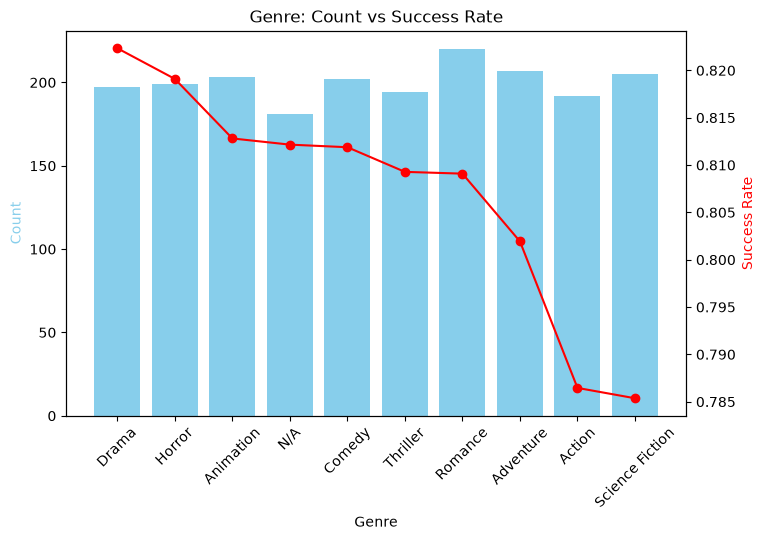

In [128]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.bar(summary['genres'], summary['count'], color='skyblue', label='Count')
ax1.set_ylabel('Count', color='skyblue')
ax1.set_xlabel('Genre')
plt.xticks(rotation=45)

ax2 = ax1.twinx()     # creates a second y-axis sharing the same x-axis
ax2.plot(summary['genres'], summary['success_rate'], color='red', marker='o', label='Success Rate')
ax2.set_ylabel('Success Rate', color='red')

plt.title('Genre: Count vs Success Rate')
plt.show()

**Findings: Genre — Common vs. Successful**

- The most common genre in the dataset is Romance (220 movies), followed by Adventure (207) and Science Fiction (205).
- The most successful genre by success rate is Drama, with an average success rate of 0.822 (~82% of Drama movies succeeded).
- Interestingly, Romance being the most common genre does not make it the most successful — Romance's success rate (0.809) ranks lower than Drama's, showing that genre popularity and genre success don't necessarily align.
- This suggests that producing more movies in a genre doesn't automatically translate to a higher success rate for that genre — quality and execution likely matter more than volume.
- Genres like Horror (0.819) and Animation (0.813) also show strong success rates, close to Drama, indicating success is fairly consistent across a few genres rather than dominated by just one.

### Q3. Do popularity / runtime / ratings correlate with success?

In [129]:
df['popularity'].corr(df['success'])

np.float64(0.046142727679267345)

In [130]:
df['runtime'].corr(df['success'])

np.float64(-0.03466632952024074)

In [131]:
df['vote_average'].corr(df['success'])

np.float64(-0.023159162552394325)

Correlation analysis indicates that Popularity, Runtime and Vote_average have near to almost Zero linear relation with Movie success.
None of these variables appear to be predictors of movie success.

#### Q4 Correlation heatmap — flag any features that are basically duplicates of each other

In [132]:
df.head()

,title,genres,budget,revenue,popularity,runtime,vote_average,success,movie_id,perfect_ratio
0,Movie 1,Romance,57755036,107323371,60.38,98,6.61,1,10749.0,1.858251
1,Movie 2,Drama,192100010,342896533,86.29,96,7.18,1,18.0,1.784990
2,Movie 3,Comedy,128521863,253206827,87.00,148,3.54,1,35.0,1.970146
3,Movie 4,Drama,156299516,89635602,72.71,118,5.99,0,18.0,0.573486
4,Movie 5,Comedy,148532820,221133868,74.83,161,4.58,1,35.0,1.488788


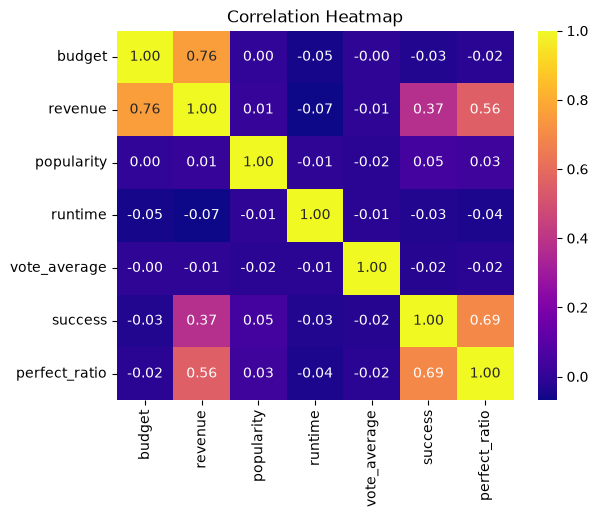

In [133]:
corr = df.drop(columns=['movie_id']).select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='plasma', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


- No numerical features exhibit extremely high correlation (|r| ≥ 0.85), indicating no strong feature redundancy.
- Budget and revenue have a strong positive correlation (r ≈ 0.75), but they represent different business metrics and are both important for analysis.
- The perfect_ratio feature is derived from budget and revenue, so its correlation with these variables is expected.
- Popularity, runtime, and vote average show weak correlations with the other numerical features.
- The movie_id column is an identifier and should not be interpreted in the correlation analysis, as its numeric values do not have quantitative meaning.
- Overall, the heatmap suggests that the dataset has low multicollinearity, allowing most numerical features to be retained for further analysis and modeling.

Q5. What is the distribution of movie budgets?

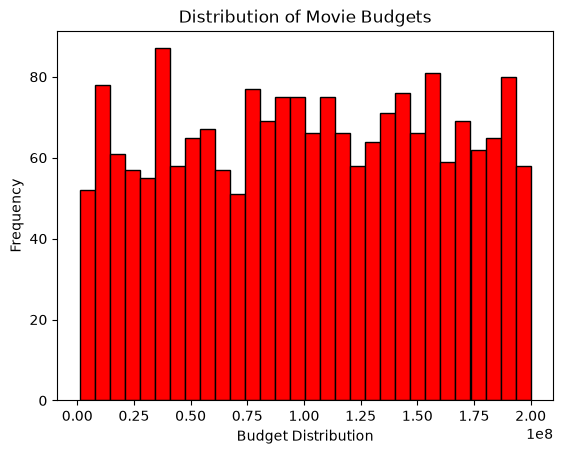

In [134]:
plt.hist(df['budget'],bins=30, color='Red', edgecolor='black')
plt.xlabel("Budget Distribution")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Budgets")
plt.show()

Insights
- Movie budgets are fairly evenly distributed across the dataset, with no single budget range dominating.
- The histogram does not exhibit significant skewness, indicating a balanced representation of both lower- and higher-budget movies.
- No major budget range appears to have an unusually high or low frequency, suggesting that the dataset includes a diverse mix of movie budgets.
- Since budgets are well spread across the range, the dataset is suitable for analyzing how production budget influences other factors such as revenue and movie success.

Q6 What is the distribution of movie revenues?

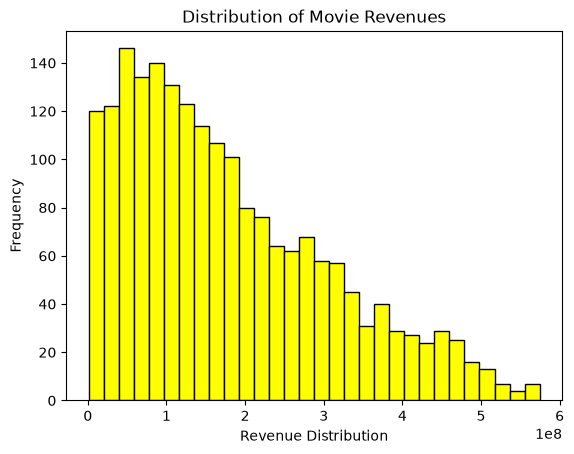

In [135]:
plt.hist(df['revenue'],bins=30, color='yellow', edgecolor='black')
plt.title("Distribution of Movie Revenues")
plt.xlabel("Revenue Distribution")
plt.ylabel("Frequency")
plt.show()

Insights:
- Revenue distribution is positively (right) skewed.
- Most movies generate lower to moderate revenues.
- Only a few blockbuster movies earn exceptionally high revenues.
- High-revenue movies are relatively rare compared to lower-grossing films.

Q7 Which genres generate the highest average revenue?

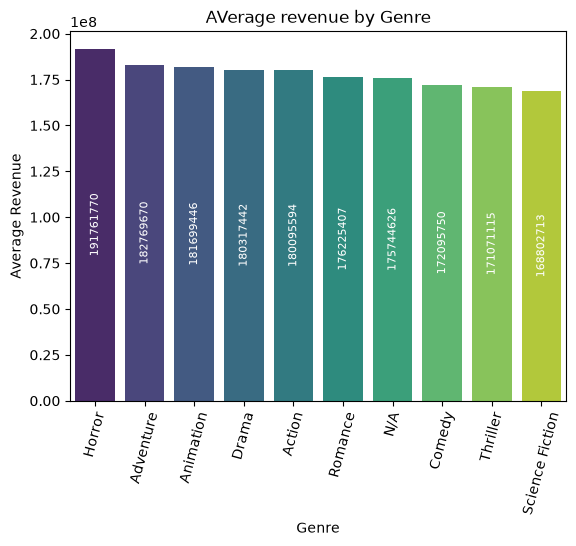

In [136]:
avg_revenue = df.groupby('genres',observed=False)['revenue'].mean().sort_values(ascending=False)

plot_avg_rev = sns.barplot(x=avg_revenue.index,y=avg_revenue.values, hue=avg_revenue.index,palette='viridis')
plt.xticks(rotation=75)
plt.title('AVerage revenue by Genre')
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
for i in plot_avg_rev.containers:
    plot_avg_rev.bar_label(i,fmt="%.0f",label_type='center',rotation=90,color='white',fontsize=8)
plt.show()

Insights:
- Horror genre has the highest average revenue.
- Science Fiction has the lowest average revenue.
- Average revenues across genres are fairly similar.
- Genre has only a modest influence on average revenue in this dataset.

Q8. Which genres require the highest average budget?

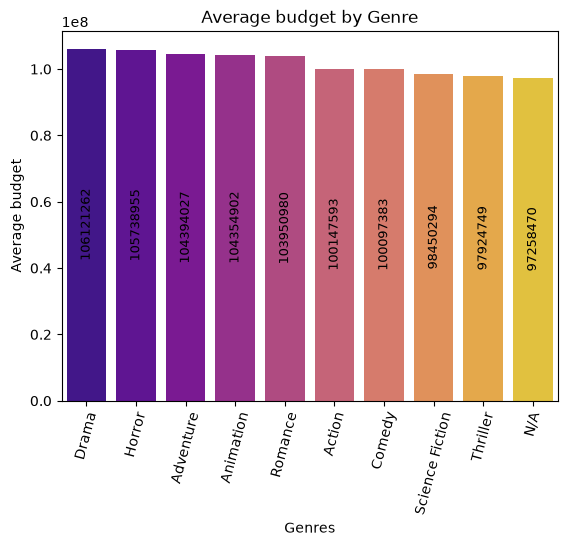

In [137]:
avg_bud = df.groupby('genres',observed=False)['budget'].mean().sort_values(ascending=False)

avg_budget = sns.barplot(x=avg_bud.index,y=avg_bud.values,hue=avg_bud.index,palette='plasma')
plt.xticks(rotation=75)
plt.title('Average budget by Genre')
plt.xlabel('Genres')
plt.ylabel('Average budget')
for i in avg_budget.containers:
    avg_budget.bar_label(i,fmt="%.0f",label_type='center',rotation=90,color='black',fontsize=9)
plt.show()

Insights:
- Drama movies have the highest average production budget, followed closely by Horror and Adventure.
- Movies with missing genre information (N/A) have the lowest average budget among all categories.
- The average budget across genres ranges from approximately $97M to $106M, indicating relatively small differences in production spending.
- Overall, production budgets are fairly consistent across genres, suggesting that genre alone does not strongly influence budget allocation in this dataset.

***The original dataset contained missing values in the genres column. Instead of dropping those records, I replaced the missing values with N/A to retain all observations during the analysis.***

Q9. Do successful movies have higher budgets than unsuccessful movies?

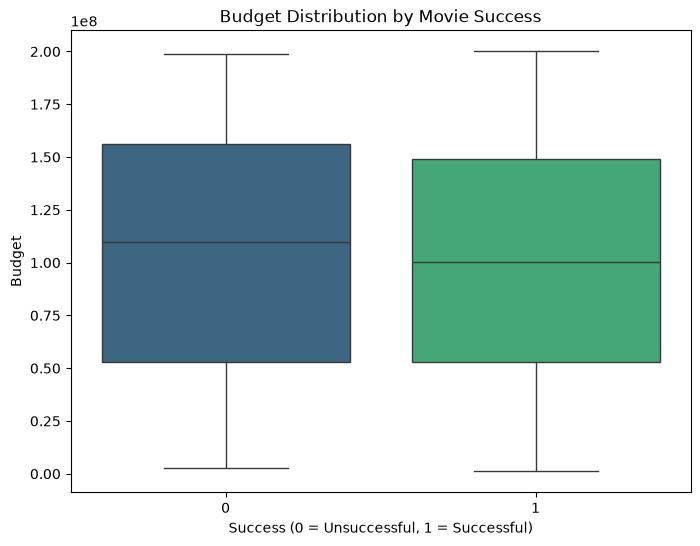

In [138]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df,x='success',y='budget',hue='success',palette='viridis',legend=False)

plt.title("Budget Distribution by Movie Success")
plt.xlabel("Success (0 = Unsuccessful, 1 = Successful)")
plt.ylabel("Budget")

plt.show()

Insights:
- The budget distributions of successful and unsuccessful movies are quite similar.
- There is no substantial difference in the median budgets between the two groups.
- This suggests that production budget alone is not a strong determinant of movie success in this dataset.

Q10. Do successful movies earn a higher revenue-to-budget ratio?

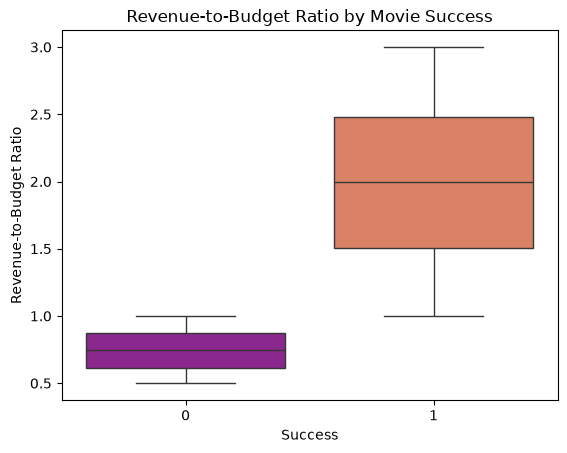

In [139]:
sns.boxplot(data=df,x='success',y='perfect_ratio',hue='success',palette='plasma',legend=False)

plt.title("Revenue-to-Budget Ratio by Movie Success")
plt.xlabel("Success")
plt.ylabel('Revenue-to-Budget Ratio')
plt.show()

Insights
- Successful movies earn a much higher revenue-to-budget ratio than unsuccessful movies.
- The median ratio for successful movies is around 2× the production budget.
- Unsuccessful movies generally earn less than their production budget (ratio < 1).
- Revenue-to-budget ratio is a strong indicator of commercial success.

Q11. Which movies achieved the highest return on investment (ROI)?

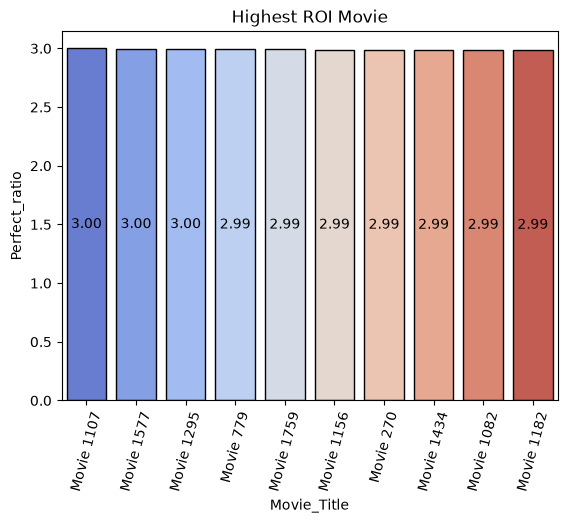

In [140]:
roi = df[['title','perfect_ratio']].sort_values(by='perfect_ratio',ascending=False).head(10)
plot_roi = sns.barplot(data=roi,x='title',y='perfect_ratio',hue='title',palette='coolwarm',legend=False,edgecolor='black')
plt.xticks(rotation=75)
plt.title('Highest ROI Movie')
plt.xlabel('Movie_Title')
plt.ylabel('Perfect_ratio')
for i in plot_roi.containers:
    plot_roi.bar_label(i,label_type='center',fmt='%.2f',color='black')
plt.show()


Insights:
- The top 10 movies recorded the highest return on investment (ROI).
- These movies earned substantially more than their production budgets.
- A high ROI indicates efficient utilization of production budget.
- Strong commercial performance is driven by multiple factors beyond budget alone.

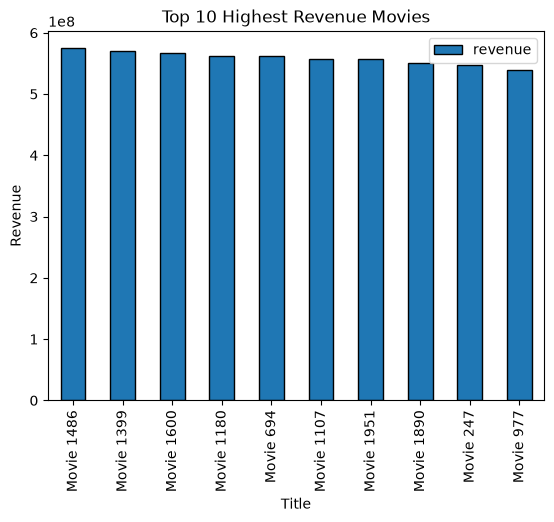

In [141]:
top_10_movie = df[['title','revenue']].sort_values(by
    ='revenue',
    ascending=False).head(10).plot(
        kind='bar',
        x='title',
        y='revenue',
        edgecolor='black')
plt.title('Top 10 Highest Revenue Movies')
plt.xlabel('Title')
plt.ylabel('Revenue')
plt.show()

Insights:
- Movie 1486 is the highest-grossing movie in the dataset.
- The top 10 movies generated revenues exceeding $540 million.
- Revenue differences among the top 10 movies are relatively small.
- These movies represent the strongest commercial performers in the dataset.

In [142]:
df.to_csv("movies_iq.csv",index=False)